# Проект "Принятие решения в бизнесе"

<div style="border:solid green 2px; padding: 30px">
 <b> Цель проекта:</b>
        
Я аналитик крупного интернет-магазина. Вместе с отделом маркетинга мне нужно подготовить список гипотез для увеличения выручки.

Цель: приоритизировать гипотезы, запустить A/B-тест и проанализировать результаты.


    

<b> План:</b>    
1) *Предобработка данных*;
    
    
    
2) *Приоритизация гипотез* : 
    

    В файле hypothesis.csv 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.
    

	Задачи: 
    
1.	Примените фреймворк ICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
    
2.	Примените фреймворк RICE для приоритизации гипотез. Отсортируйте их по убыванию приоритета.
    
3.	Укажите, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясните, почему так произошло.
    

3) *Провести и проанализировать А/В - тест*:
    
1.	Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.
    
2.	Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.
    
3.	Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.
    
4.	Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.
    
5.	Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.
    
6.	Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.
    
7.	Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.
    
8.	Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.
    
9.	Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.
    
10.	Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.
    
11.	Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.
    
12.	Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.
    
13.	Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.
    
14.	Примите решение по результатам теста и объясните его. Варианты решений:
    
а)	Остановить тест, зафиксировать победу одной из групп.
    
б)	Остановить тест, зафиксировать отсутствие различий между группами.
    
в)	Продолжить тест.

    
4) *Сделать выводы*

<div style="border:solid green 2px; padding: 30px">

<b> Описание данных:</b> 
 
 
Данные для первой части:
    
    
 1)	Файл data/hypothesis.csv : 

    - Hypothesis — краткое описание гипотезы;
    - Reach — охват пользователей по 10-балльной шкале;
    - Impact — влияние на пользователей по 10-балльной шкале;
    - Confidence — уверенность в гипотезе по 10-балльной шкале;
    - Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.


Данные для второй части:
    
    
2)	Файл data/orders.csv : 

    - transactionId — идентификатор заказа;
    - visitorId — идентификатор пользователя, совершившего заказ;
    - date — дата, когда был совершён заказ;
    - revenue — выручка заказа;
    - group — группа A/B-теста, в которую попал заказ.



3)	Файл data/visitors.csv :

    - date — дата;
    - group — группа A/B-теста;
    - visitors — количество пользователей в указанную дату в указанной группе A/B-теста.

In [1]:
# Импортируем необходимые библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import datetime as dt
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Настроим более приятное визуально отображение чисел с плавающей запятой:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Устанавим максимальное количество столбцов для отображентя при выводе DataFrame в консоль:
pd.options.display.max_columns = 30

## Шаг 1. Загрузка данных

### Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы

In [3]:
from pathlib import Path

DATA_DIR = Path('data')
orders = pd.read_csv(DATA_DIR / 'orders.csv')
visitors = pd.read_csv(DATA_DIR / 'visitors.csv')
hypothesis = pd.read_csv(DATA_DIR / 'hypothesis.csv')
print('Файлы успешно прочитаны из', DATA_DIR.resolve())

Файлы успешно прочтены!


### Выведем первые строки каждого набора данных и изучим общую информацию о каждом датафрейме

In [5]:
display(Markdown('#### Датасет orders:'))
display(orders.head())

display(Markdown('#### Датасет visitors:'))
display(visitors.head())

display(Markdown('#### Датасет hypothesis:'))
display(hypothesis.head())

#### Датасет orders:

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


#### Датасет visitors:

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


#### Датасет hypothesis:

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


Создадим функцию для вывода базовой информации по базам данных:

In [9]:
def basic_data_info(data):
    display(Markdown('<span style="color: green;"><strong>Информация о DataFrame:</strong></span>'))
    display(data.info())
    
    display(Markdown('<span style="color: green;"><strong>Аналитическая сводка:</strong></span>'))
    display(data.describe())
    
    display(Markdown('<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>'))
    display(data.isna().sum())
    
    display(Markdown('<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>'))
    display(data.duplicated().sum())

In [10]:
# Базовая информация по orders:
basic_data_info(orders)

<span style="color: green;"><strong>Информация о DataFrame:</strong></span>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


None

<span style="color: green;"><strong>Аналитическая сводка:</strong></span>

,transactionId,visitorId,revenue
count,"1,197.00","1,197.00","1,197.00"
mean,"2,155,621,385.53","2,165,960,143.10","8,348.01"
std,"1,229,084,904.76","1,236,014,192.15","39,191.13"
min,"1,062,393.00","5,114,589.00",50.00
25%,"1,166,775,572.00","1,111,826,046.00","1,220.00"
50%,"2,145,193,898.00","2,217,984,702.00","2,978.00"
75%,"3,237,740,112.00","3,177,606,451.00","8,290.00"
max,"4,293,855,558.00","4,283,872,382.00","1,294,500.00"


<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>

transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>

0

In [11]:
# Базовая информация по visitors:
basic_data_info(visitors)

<span style="color: green;"><strong>Информация о DataFrame:</strong></span>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


None

<span style="color: green;"><strong>Аналитическая сводка:</strong></span>

,visitors
count,62.00
mean,607.29
std,114.40
min,361.00
25%,534.00
50%,624.50
75%,710.50
max,770.00


<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>

date        0
group       0
visitors    0
dtype: int64

<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>

0

In [12]:
# Базовая информация по hypothesis:
basic_data_info(hypothesis)

<span style="color: green;"><strong>Информация о DataFrame:</strong></span>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


None

<span style="color: green;"><strong>Аналитическая сводка:</strong></span>

,Reach,Impact,Confidence,Efforts
count,9.00,9.00,9.00,9.00
mean,4.78,4.78,5.56,4.89
std,3.15,3.19,3.05,2.80
min,1.00,1.00,1.00,1.00
25%,3.00,3.00,3.00,3.00
50%,3.00,3.00,7.00,5.00
75%,8.00,7.00,8.00,6.00
max,10.00,10.00,9.00,10.00


<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>

Hypothesis    0
Reach         0
Impact        0
Confidence    0
Efforts       0
dtype: int64

<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>

0

<div style="border:solid  green 4px; padding: 30px">
    
<b> ВЫВОД:</b>
    
    
- В датасете orders 1197 строк и 5 столбцов. Пропусков нет, явных дубликатов тоже нет.
    
- В датасете visitors 62 строк и 3 столбца. Пропусков нет, явных дубликатов тоже нет.

- В датасете hypothesis 9 строк и 5 столбцов. Пропусков нет, явных дубликатов тоже нет.

- Нужно привести столбцы date в датафреймов orders и visitors к нужному типу из object в datetime.
    
- Также можно привести названия столбцов в фреймах данных к змеиному стилю (snake_case).
   

## Шаг 2. Предобработка данных

### Приведем столбец date датасетов orders и visitors к типу даты pandas

In [13]:
# Преобразование дат:
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
visitors['date'] = pd.to_datetime(visitors['date'], format='%Y-%m-%d')

In [14]:
display(orders.info())
display(visitors.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


None

### Применим к названиям столбцов правила змеиного стиля

In [15]:
data_sets = [orders, visitors, hypothesis]

In [16]:
def rename_columns(dataframes):   # находим каждую заглавную букву и добавляем _ перед ней, 
    for df in dataframes: # .str.lstrip('_') удаляет ведущий символ _, если он есть - если первая буква была заглавной
        df.columns = df.columns.str.replace('([A-Z])', r'_\1', regex=True).str.lower().str.lstrip('_')

# Применяем функцию к списку DataFrame:
rename_columns(data_sets)

# Проверка новых названий столбцов:
for df in data_sets:
    print(df.columns.tolist())

['transaction_id', 'visitor_id', 'date', 'revenue', 'group']
['date', 'group', 'visitors']
['hypothesis', 'reach', 'impact', 'confidence', 'efforts']


### Проверим корректность значений некоторых столбцов:

In [18]:
print(orders['group'].unique())
print(visitors['group'].unique())

['B' 'A']
['A' 'B']


<div style="border:solid  green 4px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Мы привели столбец date датасетов orders и visitors к типу даты pandas, а также прменили к названиям столбцов всех датасетов правила змеиного стиля: добавили нижнее подчеркивание между словами в названиях столбцов и привели названия  к нижнему регистру.

## Шаг 3. Приоритизация гипотез

В файле hypothesis.csv 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.



In [19]:
# Укажем максимальную ширину столбцов и разрешим отображать текст в ячейках без обрезки:
pd.set_option('display.max_colwidth', None)
display(hypothesis)

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


### Применим фреймворк ICE для приоритизации гипотез. Отсортируем их по убыванию приоритета:

In [20]:
hypothesis['ICE'] = (
    hypothesis['impact'] * hypothesis['confidence']
    ) / hypothesis['efforts']
display(
hypothesis[['hypothesis', 'ICE']]
.sort_values(by='ICE', ascending=False))


,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Наиболее приоритетные гипотезы по ICE - это:
 
1. 'Запустить акцию, дающую скидку на товар в день рождения' - c показателем ICE = 16.20;
    
2. 'Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей' (ICE = 13.33);
    
3. и 'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок' (ICE = 11.20).
    
    
Наименее приоритетные гипотезы : 'Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар' и 'Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей' с показателями ICE = 1.12 и 1.00.

### Применим фреймворк RICE для приоритизации гипотез. Отсортируем их по убыванию приоритета:

In [21]:
hypothesis['RICE'] = (
    hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']
    ) / hypothesis['efforts']
display(hypothesis[['hypothesis','RICE']].sort_values(by='RICE', ascending=False))

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.00
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.00
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.00
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.00


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Наиболее приоритетные гипотезы по RICE - это:
    
1. 'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок' (RICE = 112.00), гипотеза, которая по ICE была на 3-м месте по приоритизации;
    
2. 'Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа' (RICE = 56.00) ;
    
3. 'Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей' (RICE = 40.00), гипотеза, которая юыла второй по приоритизации по ICE. 
   
    
Наименее приоритетные гипотезы : 'Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов' и 'Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей' с показателями ICE = 4.00 и 3.00. Эти гипотезы были наименее приоритетны и по значениям ICE. 

### Укажем, как изменилась приоритизация гипотез при применении RICE вместо ICE и почему так произошло :

In [22]:
# Применение градиентного окрашивания:
styled_hypothesis = hypothesis.style.background_gradient(subset=['ICE', 'RICE'], cmap='Greens')

display(styled_hypothesis)

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.333333,40.000000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.000000,4.000000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.000000,56.000000
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.125000,9.000000
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.000000,3.000000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.333333,4.000000
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.000000,40.000000
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.200000,112.000000
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.200000,16.200000


In [23]:
hypothesis_sorted_by_rice = hypothesis.sort_values(by='RICE', ascending=False)

hypothesis_sorted_by_rice.style \
    .background_gradient(subset=['ICE', 'RICE'], cmap='Greens')

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.200000,112.000000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.000000,56.000000
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.333333,40.000000
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.000000,40.000000
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.200000,16.200000
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.125000,9.000000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.000000,4.000000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.333333,4.000000
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.000000,3.000000


In [24]:
# hypothesis_sorted_by_rice.style.hide_index()

<div style="border:solid  green 4px; padding: 30px">
    
<b> ВЫВОД:</b>
    
При применении фрейсморка ICE на первом месте оказалась гипотеза № 8 'Запустить акцию, дающую скидку на товар в день рождения'.Но при применении фрейморка RICE приоритетность этой гипотезы упала до 5-го места.

При применении фрейсморка RICE на первом месте оказалась гипотеза № 7 'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок', хотя она была 3-й по приоритету гипотезой при применении фреймворка ICE. 

Гипотеза № 2 'Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа' была на 5-м месте по приоритету при применении фрейворка ICE, но уже на 2-м месте при применении фрейморка RICE. 

Такие изменения могут быть связаны с тем, что во фреймворке ICE не используется параметр "REACH", который показывает охват - пользователей, которые увидят новую функциональность продукта, которую мы хотим внести. У гипотезы № 8 'Запустить акцию, дающую скидку на товар в день рождения' параметр 'REACH' = 1, а у гипотезы № 7 параметр 'REACH' = 10, что означало бы, что ни один пользователь, который зашел на сайт интернет-магазина, не будет пропущен. 

    
Данные два метода приоритизации гипотез различаются друг от друга, хоть и гипотезы, ставшие наименее приоритетными, совпали. Однако если мы ищем гипотезу, которая охватит больший круг пользователей, то нам лучше выбирать фрейворк RICE. А если же этот компонент не так важен - то ICE.
    
<b> Таким образом</b>, 
    
в нашем случае для проведения A/B теста нам нужно взять гипотезы № 7 'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок'. 
    
Второй гипотезой для проведения А/В теста можно было бы взять гипотезу № 0 'Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей'. 

## Шаг 4. Анализ A/B-теста

Мы провели A/B-тест и получили результаты, которые описаны в файлах orders.csv и visitors.csv.

**ПРОАНАЛИЗИРУЕМ A / B-ТЕСТ:**

In [25]:
display(Markdown('<span style="color: green;"><strong>Датасет orders:</strong></span>'))
display(orders.head(10))

display(HTML('<br><br>'))  # двойной пробел между таблицами

display(Markdown('<span style="color: green;"><strong>Датасет visitors:</strong></span>'))
display(visitors.head(10))

<span style="color: green;"><strong>Датасет orders:</strong></span>

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
5,182168103,935554773,2019-08-15,2210,B
6,398296753,2900797465,2019-08-15,1860,B
7,2626614568,78758296,2019-08-15,1044,A
8,1576988021,295230930,2019-08-15,13710,A
9,1506739906,1882260405,2019-08-15,1855,B


<span style="color: green;"><strong>Датасет visitors:</strong></span>

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


**Подготовим агрегированнные кумулятивные данные по уникальным парам значений дат и групп А/В-теста:**

In [26]:
dates_groups = orders[['date', 'group']].drop_duplicates()

# Агрегированные кумулятивные по дням данные о заказах:
orders_aggregated = dates_groups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])


# Агрегированные кумулятивные по дням данные о посетителях:
visitors_aggregated = dates_groups.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])



# Объединим кумулятивные данные в одной таблице:
cumulative_data = orders_aggregated.merge(
    visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulative_data.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

display(cumulative_data.head(10))

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845
5,2019-08-03,B,61,59,380996,1803
6,2019-08-04,A,84,77,425699,2562
7,2019-08-04,B,78,75,489567,2573
8,2019-08-05,A,109,100,549917,3318
9,2019-08-05,B,101,98,581995,3280


### Построим график кумулятивной выручки по группам. Сделаем выводы и предположения:

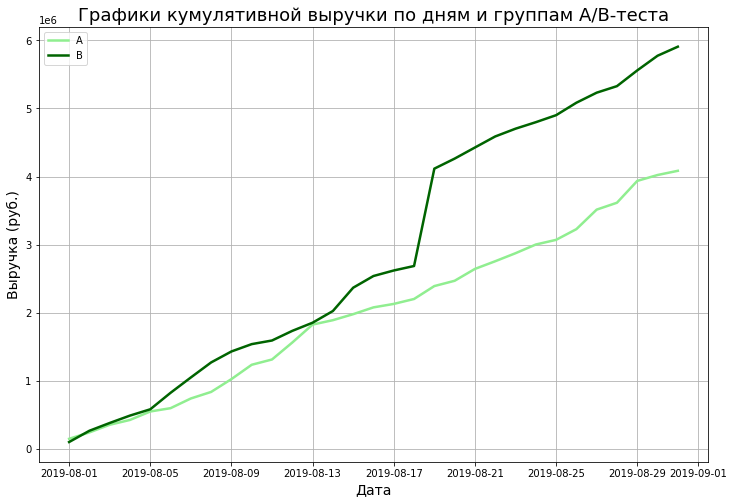

In [27]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_a = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_b = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]



# СТРОИМ ГРАФИК:
plt.figure(figsize=(12, 8))

# Строим график выручки группы A (темно-зеленый):
plt.plot(
    cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='A', 
    color='lightgreen', linewidth=2.5
)

# Строим график выручки группы B (синий):
plt.plot(
    cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='B', 
    color='darkgreen', linewidth=2.5
)

plt.grid(visible=True)
plt.title('Графики кумулятивной выручки по дням и группам A/B-теста', fontsize=18)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Выручка (руб.)', fontsize=14)
plt.legend()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Выручка почти равномерно увеличивается в течение всего теста. Это хороший знак.

Однако график выручки группы В в одной точке резко растет. Это может сигнализировать о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке.
    
Группа В на пробяжении всего периода теста показывала результаты кумулятивной виручки выше, чем группа А, кроме периодов от от 2019-08-01 до 2019-08-05 и 2019-08-13, где группы показали практически одинаковый результат. Но после 2019-08-18 произошел резкий скачок в покупках в группе В.

### Построим график кумулятивного среднего чека по группам:

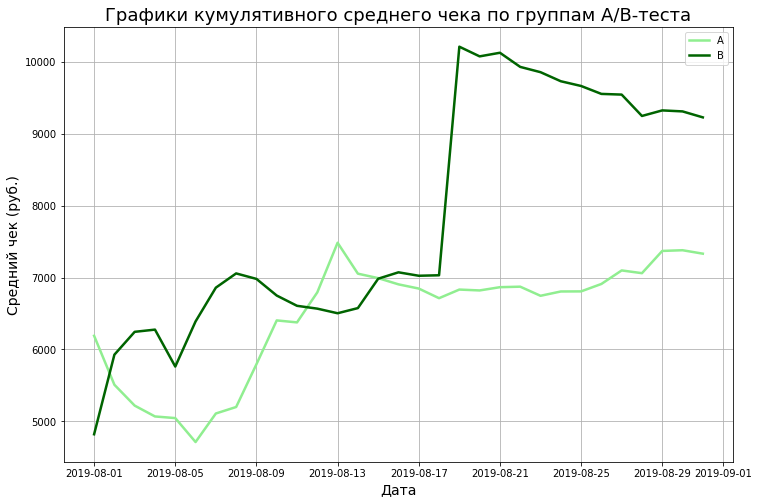

In [28]:
plt.figure(figsize=(12, 8))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue']/cumulative_revenue_a['orders'], label='A',
         color='lightgreen', linewidth=2.5)
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue']/cumulative_revenue_b['orders'], label='B',
         color='darkgreen', linewidth=2.5)


plt.grid(visible=True)
plt.title('Графики кумулятивного среднего чека по группам A/B-теста', fontsize=18)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Средний чек (руб.)', fontsize=14)
plt.legend()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Средние чеки после флуктуаций в начале тоже становятся более равномерными с чуть дальше середины теста: установился для группы A и даже немного стал расти и продолжает медленно падать для группы B. Однако мы видим резкий всплеск кумулятивного показателя суммы среднего чека в группе В на 2019-08-18 (так же как и на графике кумулятивной выручки по дням и группам). Возможно, в группу B теста тогда попали сильно крупные заказы. Тогда группе В нужно больше данных, чтобы прийти к реальному среднему чеку и установиться на его уровне. То же самое случилось и в группе А после 2019-08-06. 
   
Средний чек группы В в первый день был существенно ниже, после чего средний чек группы В был почти постоянно выше (кроме 2019-08-13, где средний чек группы В были ниже).

### Построим график относительного изменения кумулятивного среднего чека группы B к группе A:

In [29]:
merged_cumulative_revenue = cumulative_revenue_a.merge(cumulative_revenue_b, left_on='date', right_on='date', 
how='left', suffixes=['_a', '_b']) # параметр suffixes используется для указания суффиксов, которые будут добавлены к именам столбцов в случае, если в обоих объединяемых DataFrame есть столбцы с одинаковыми именами

display(merged_cumulative_revenue.head(15))

,date,revenue_a,orders_a,revenue_b,orders_b
0,2019-08-01,148579,24,101217,21
1,2019-08-02,242401,44,266748,45
2,2019-08-03,354874,68,380996,61
3,2019-08-04,425699,84,489567,78
4,2019-08-05,549917,109,581995,101
5,2019-08-06,598401,127,824337,129
6,2019-08-07,740818,145,1049671,153
7,2019-08-08,837097,161,1270589,180
8,2019-08-09,1025603,177,1431401,205
9,2019-08-10,1236098,193,1539203,228


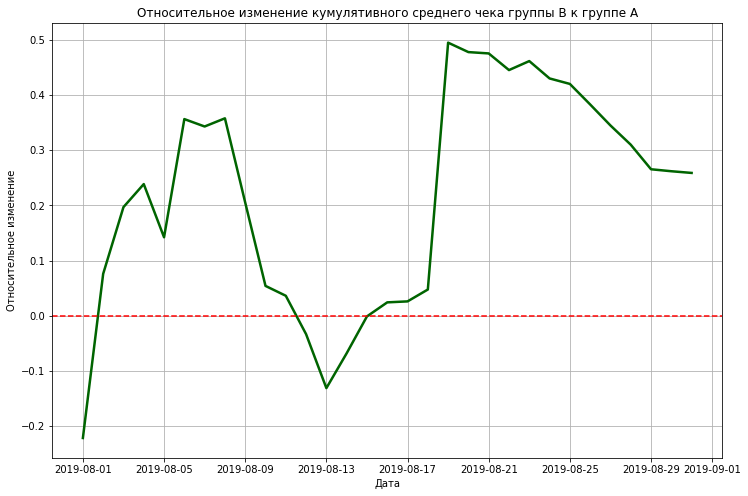

In [30]:
plt.figure(figsize=(12, 8))

plt.plot(merged_cumulative_revenue['date'], 
         (merged_cumulative_revenue['revenue_b']/merged_cumulative_revenue['orders_b'])/
(merged_cumulative_revenue['revenue_a']/merged_cumulative_revenue['orders_a'])-1, 
         color='darkgreen', linewidth=2.5)

plt.title('Относительное изменение кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение')
plt.grid(True)
# добавляем ось X:
plt.axhline(y=0, color='red', linestyle='--')

plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
В нескольких точках график различия между группами А и В резко «скачет». Где-то спрятались крупные аномальные заказы и выбросы. 

### Построим график кумулятивного среднего количества заказов на посетителя по группам:

In [31]:
cumulative_data['conversion'] = cumulative_data['orders']/cumulative_data['visitors']

# отделяем данные по группе A:
cumulative_data_a = cumulative_data[cumulative_data['group']=='A']
# отделяем данные по группе B:
cumulative_data_b = cumulative_data[cumulative_data['group']=='B']


display(Markdown('<span style="color: green;"><strong>Конверсия в группе А:</strong></span>'))
display(cumulative_data_a.head(10))

display(HTML('<br>'))  # двойной пробел между таблицами

display(Markdown('<span style="color: green;"><strong>Конверсия в группе В:</strong></span>'))
display(cumulative_data_b.head(10))


<span style="color: green;"><strong>Конверсия в группе А:</strong></span>

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,24,20,148579,719,0.03
2,2019-08-02,A,44,38,242401,1338,0.03
4,2019-08-03,A,68,62,354874,1845,0.04
6,2019-08-04,A,84,77,425699,2562,0.03
8,2019-08-05,A,109,100,549917,3318,0.03
10,2019-08-06,A,127,114,598401,3985,0.03
12,2019-08-07,A,145,131,740818,4629,0.03
14,2019-08-08,A,161,146,837097,5239,0.03
16,2019-08-09,A,177,159,1025603,5856,0.03
18,2019-08-10,A,193,175,1236098,6262,0.03


<span style="color: green;"><strong>Конверсия в группе В:</strong></span>

,date,group,orders,buyers,revenue,visitors,conversion
1,2019-08-01,B,21,20,101217,713,0.03
3,2019-08-02,B,45,43,266748,1294,0.03
5,2019-08-03,B,61,59,380996,1803,0.03
7,2019-08-04,B,78,75,489567,2573,0.03
9,2019-08-05,B,101,98,581995,3280,0.03
11,2019-08-06,B,129,123,824337,3935,0.03
13,2019-08-07,B,153,146,1049671,4644,0.03
15,2019-08-08,B,180,171,1270589,5298,0.03
17,2019-08-09,B,205,193,1431401,5908,0.03
19,2019-08-10,B,228,215,1539203,6277,0.04


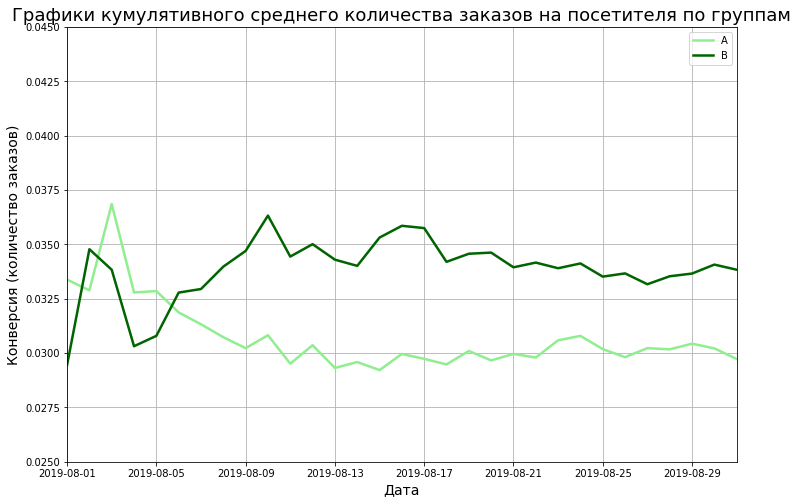

In [32]:

# СТРОИМ ГРАФИК:
plt.figure(figsize=(12, 8))

plt.plot(cumulative_data_a['date'], cumulative_data_a['conversion'], label='A',
         color='lightgreen', linewidth=2.5)

plt.plot(cumulative_data_b['date'], cumulative_data_b['conversion'], label='B',
        color='darkgreen', linewidth=2.5)

plt.grid(visible=True)
plt.title('Графики кумулятивного среднего количества заказов на посетителя по группам', fontsize=18)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Конверсия (количество заказов)', fontsize=14)
# задаем масштаб осей:
plt.axis([dt.datetime(2019, 8, 1), dt.datetime(2019, 8, 31), 0.025, 0.045]) 
plt.legend()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Группы колебались в начале теста одинаково, сначала резкий скачок, потом падение, до 2019-08-05, но потом конверсия группы В стала расти, когда как конвесрия группы А продолжала падать, но после 2019-08-09 их уровни относительно стабилизировались и зафиксировались.

### Построим график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A:

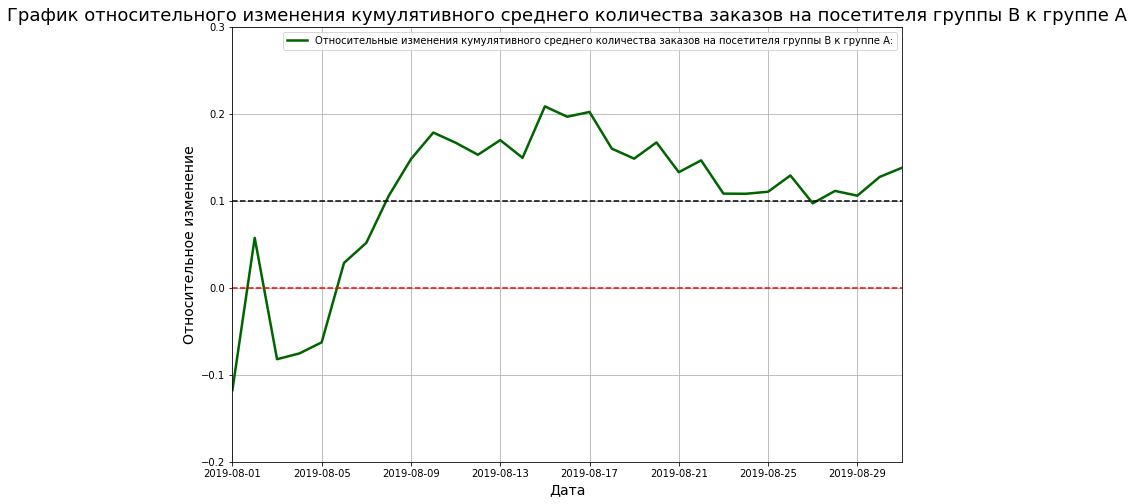

In [33]:
merged_cumulative_conversions = cumulative_data_a[['date','conversion']].merge(
    cumulative_data_b[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['_a', '_b']
)


plt.figure(figsize=(12, 8))
plt.plot(merged_cumulative_conversions['date'], 
         merged_cumulative_conversions['conversion_b']/merged_cumulative_conversions['conversion_a']-1, 
         color='darkgreen', linewidth=2.5,
         label="Относительные изменения кумулятивного среднего количества заказов на посетителя группы B к группе A:")
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A' , fontsize=18)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Относительное изменение', fontsize=14)
plt.grid(True)
plt.legend()

plt.axhline(y=0, color='red', linestyle='--')
plt.axhline(y=0.1, color='black', linestyle='--')
plt.axis([pd.to_datetime("2019-08-01"), pd.to_datetime("2019-08-31"), -0.2, 0.3])

plt.show()


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
В начале теста группа B значительно проигрывала группе A, затем после повторного падения вырвалась вперёд после 2019-08-07 и держалось выше с некоторыми колебаниями до 2019-08-27, но потом снова чтало выше и постепенно стало расти. 

В целом отношение среднего количества заказов на посетителя ещё не установилось, и сейчас делать какие-либо выводы по тесту преждевременно, хоть и на протяжении периода с 7 августа по 26 августа прирост в среднем составил около 10 %. 
    
Поэтому, нужно проанализировать аномалии. 

### Построим точечный график количества заказов по пользователям:

In [34]:
display(orders.head())

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [35]:
orders_by_users = orders.groupby('visitor_id', as_index=False).agg({'transaction_id': 'nunique'})
orders_by_users.columns = ['user_id', 'number_of_orders']

styled_orders_by_users = orders_by_users.style.set_table_styles([
    {'selector': 'th',  # Стилизация заголовков таблицы
     'props': [('background-color', '#A8E4A0'),  # Зеленый цвет
               ('color', 'black'),  # Цвет текста
               ('font-style', 'italic'),  # Курсивный текст
               ('font-weight', 'normal')]}  # Не жирный текст
])

display(styled_orders_by_users)


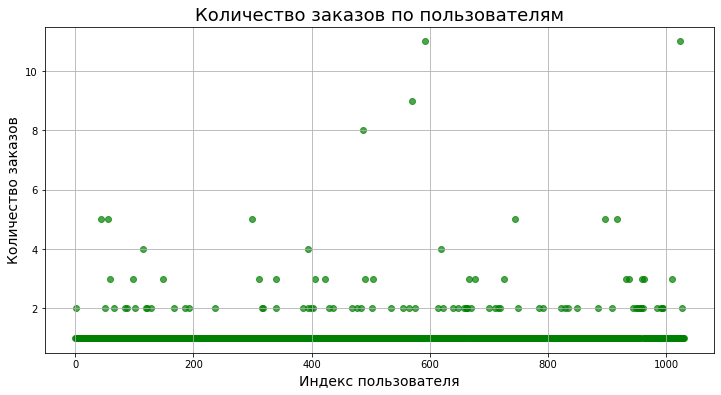

In [36]:
x_values = pd.Series(range(0,len(orders_by_users)))

plt.figure(figsize=(12, 6))

plt.scatter(x_values, orders_by_users['number_of_orders'], alpha=0.7, color='green')
plt.title('Количество заказов по пользователям', fontsize=18)
plt.xlabel('Индекс пользователя', fontsize=14)
plt.ylabel('Количество заказов', fontsize=14)
plt.grid(True)
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Есть немного пользователей, совершивших большое количество заказов. По графику можно выбрать примерную границу аномального количества заказов : 3-4 заказа. Но чтобы точно указать границу выбросов, нужно понять точную долю таких пользователей отсносительно остальных. 
    
Принято отсеивать от 1% до 5% наблюдений с крайними значениями. 

### Посчитаем 95-й и 99-й перцентили количества заказов на пользователя. Выберем границу для определения аномальных пользователей:

In [37]:
percentiles = np.percentile(orders_by_users['number_of_orders'], [95, 99])
print(f"95-й и 99-й перцентили количества заказов на пользователя: {percentiles}")

95-й и 99-й перцентили количества заказов на пользователя: [2. 4.]


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Не более 5% пользователей делают 2 заказа и не более 1% пользователей 4 заказа.
    
Разумно выбрать 2 или 3 заказа на одного пользователя за верхнюю границу числа заказов и отсеять аномальных пользователей по ней. 

### Построим точечный график стоимостей заказов:

In [38]:
# Максимальное значение в столбце revenue:
max_revenue = orders['revenue'].max()
print("Максимальное значение revenue:", max_revenue, 'руб.')

# Минимальное значение в столбце revenue:
min_revenue = orders['revenue'].min()
print("Минимальное значение revenue:", min_revenue, 'руб.')

Максимальное значение revenue: 1294500 руб.
Минимальное значение revenue: 50 руб.


In [39]:
# Посмотрим на топ-10 самых дорогих заказов:
display(orders.sort_values(by='revenue', ascending=False).head(10))

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,1294500,B
1196,3936777065,2108080724,2019-08-15,202740,B
858,192721366,1316129916,2019-08-27,93940,A
1136,666610489,1307669133,2019-08-13,92550,A
744,3668308183,888512513,2019-08-27,86620,B
682,1216533772,4266935830,2019-08-29,78990,B
662,1811671147,4266935830,2019-08-29,78990,A
743,3603576309,4133034833,2019-08-09,67990,A
1103,1348774318,1164614297,2019-08-12,66350,A
1099,316924019,148427295,2019-08-12,65710,A


In [40]:
# Посмотрим на топ-10 самых дешевых заказов:
display(orders.sort_values(by='revenue', ascending=True).head(10))

,transaction_id,visitor_id,date,revenue,group
584,1126146019,2705308997,2019-08-20,50,A
1091,750632879,4256040402,2019-08-12,50,A
756,125335873,3423937755,2019-08-30,50,B
459,863448794,2738601405,2019-08-19,50,B
1013,83566152,232979603,2019-08-31,60,A
933,3760662696,3577713868,2019-08-27,60,B
404,2052514069,1995481842,2019-08-28,70,B
908,3352225027,1807547430,2019-08-05,75,B
307,1404959653,3896738923,2019-08-18,76,A
878,3315359627,1831956319,2019-08-05,90,A


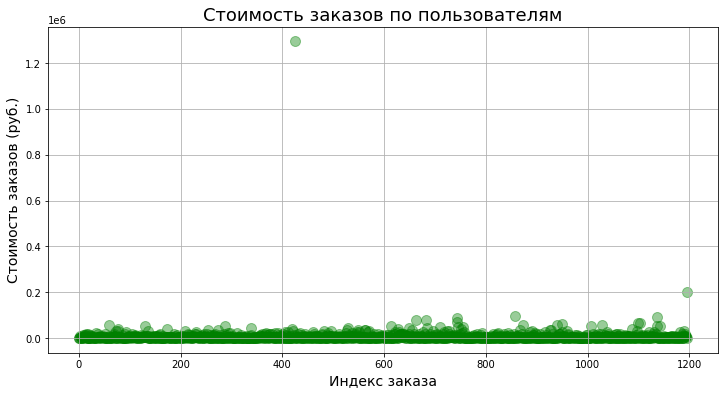

In [41]:
x_values = pd.Series(range(0,len(orders)))

plt.figure(figsize=(12, 6))

plt.scatter(x_values, orders['revenue'], alpha=0.4, color='green', s=100)
plt.title('Стоимость заказов по пользователям', fontsize=18)
plt.xlabel('Индекс заказа', fontsize=14)
plt.ylabel('Стоимость заказов (руб.)', fontsize=14)
plt.grid(True)
plt.show()

По графику 0.1 по оси Y соответствует * 1e-6 = 0.1 * 1.000.000 = 100.000. 

Проведем линию - границу 95-го перцентиля:

Text(0, 0.5, 'Стоимость заказов (руб.)')

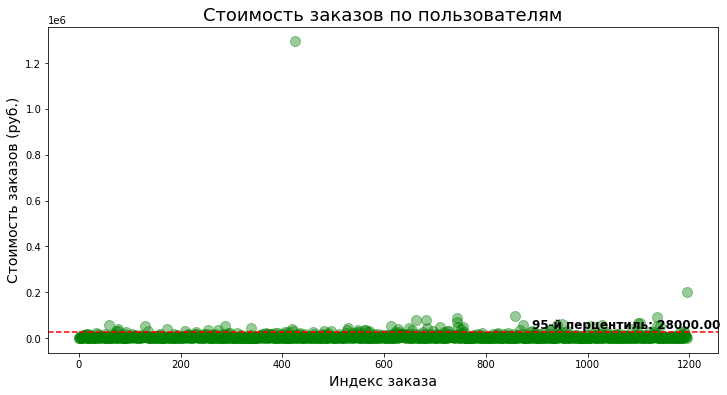

In [42]:
percentile_95 = np.percentile(orders['revenue'], 95)

plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders['revenue'], alpha=0.4, color='green', s=100)

# Строим линию 95-го перцентиля:
plt.axhline(y=percentile_95, color='red', linestyle='--', label=f'95-й перцентиль: {percentile_95:.2f}')
# plt.legend()  # или :
plt.text(x=max(x_values)*0.9, y=percentile_95 * 1.02, 
         s=f'95-й перцентиль: {percentile_95:.2f}', 
         color='black', fontsize=12, fontweight='bold', ha='center', va = 'bottom')


plt.title('Стоимость заказов по пользователям', fontsize=18)
plt.xlabel('Индекс заказа', fontsize=14)
plt.ylabel('Стоимость заказов (руб.)', fontsize=14)

Изменим масштаб графика, чтобы увидеть значение, по которому проходит 95-й перцентиль:

Text(0, 0.5, 'Стоимость заказов (руб.)')

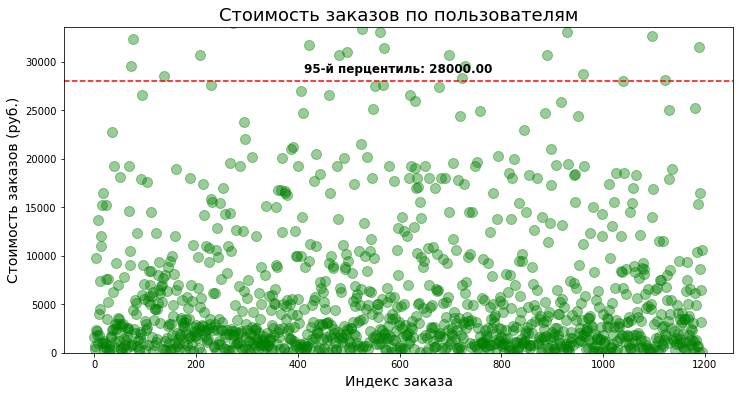

In [43]:
percentile_95 = np.percentile(orders['revenue'], 95)

plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders['revenue'], alpha=0.4, color='green', s=100)

# Строим линию 95-го перцентиля:
plt.axhline(y=percentile_95, color='red', linestyle='--')
            
# Определяем координаты для подписи (по центру графика)
x_middle = (max(x_values) - min(x_values)) / 2  # Примерно центр оси X
y_position = percentile_95 * 1.02  # Чуть выше линии, чтобы не перекрывала

# Добавляем подпись прямо на линии
plt.text(x_middle, y_position, 
         f'95-й перцентиль: {percentile_95:.2f}', 
         color='black', fontsize=12, fontweight='bold', ha='center', va='bottom')

# Устанавливаем лимиты оси Y, чтобы лучше видеть 95-й перцентиль:
plt.ylim(0, percentile_95 * 1.2)  # Верхний лимит чуть выше 95-го перцентиля

plt.title('Стоимость заказов по пользователям', fontsize=18)
plt.xlabel('Индекс заказа', fontsize=14)
plt.ylabel('Стоимость заказов (руб.)', fontsize=14)

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Есть совсем мало дорогих заказов. По графикам можно выбрать примерную границу аномальных заказов: 28.000 (руб.). Но для более точного определения границы выбросов, посчитаем 95-й и 99-й перцентили стоимости заказов.

### Посчитаем 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов:

In [44]:
percentiles = np.percentile(orders['revenue'], [95, 99])
print(f"95-й и 99-й перцентили стоимости заказов: {percentiles}")

95-й и 99-й перцентили стоимости заказов: [28000.  58233.2]


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Не более 5% заказов имеют стоимость дороже 28.000 (руб.) и не более 1% заказов - дороже  58.233,2 (руб.).
    
Разумно выбрать за верхнюю границу стоимости одного заказа 30.000 (руб.) и отсеять аномально дорогие заказы. 

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным:

Для начала сформулируем гипотезы:

•	**Нулевая**: различий в среднем количестве заказов на посетителя между группами нет, они равны. 

•	**Альтернативная**: различия в среднем между группами есть.

In [45]:
#Выведем названия толбцов датасета orders:
display(orders.columns.tolist())

['transaction_id', 'visitor_id', 'date', 'revenue', 'group']

Создадим два датасета для пользователей в каждом сегменте (А и В), которые заказывали хотя бы 1 раз, и укажем число совершённых заказов:

In [46]:
# Датафрейм со средним количеством заказов на посетителя в группе А:
orders_by_users_a = orders[orders['group'] == 'A'].groupby('visitor_id', as_index=False).agg({'transaction_id': 'nunique'})
orders_by_users_a.columns = ['user_id', 'number_of_orders']

# Датафрейм со средним количеством заказов на посетителя в группе В:
orders_by_users_b = orders[orders['group'] == 'B'].groupby('visitor_id', as_index=False).agg({'transaction_id': 'nunique'})
orders_by_users_b.columns = ['user_id', 'number_of_orders']

In [47]:
display(Markdown('<span style="color: green;"><strong>Датасет orders_by_users_a:</strong></span>'))
display(orders_by_users_a.head())

display(HTML('<br><br>'))  # двойной пробел между таблицами

display(Markdown('<span style="color: green;"><strong> Датасет orders_by_users_b:</strong></span>'))
display(orders_by_users_b.head())

display(HTML('<br><br>'))  # двойной пробел между таблицами

display(Markdown('<span style="color: green;"><strong>Датасет visitors:</strong></span>'))
display(visitors.head())

<span style="color: green;"><strong>Датасет orders_by_users_a:</strong></span>

,user_id,number_of_orders
0,8300375,1
1,11685486,1
2,54447517,1
3,66685450,1
4,78758296,1


<span style="color: green;"><strong> Датасет orders_by_users_b:</strong></span>

,user_id,number_of_orders
0,5114589,1
1,6958315,1
2,8300375,1
3,39475350,1
4,47206413,1


<span style="color: green;"><strong>Датасет visitors:</strong></span>

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


Объявим переменные sample_a и sample_b, где пользователям с заказами будет соответствовать число заказов этого пользователя, а пользователям, которые не сделали ни одного заказа (из датасета visitors) — нули:

In [48]:
sample_a = pd.concat([
    orders_by_users_a['number_of_orders'],
    pd.Series(0, index=np.arange(visitors[visitors['group'] == 'A']['visitors'].sum() - len(orders_by_users_a)), name='orders')
], axis=0)

sample_b = pd.concat([
    orders_by_users_b['number_of_orders'],
    pd.Series(0, index=np.arange(visitors[visitors['group'] == 'B']['visitors'].sum() - len(orders_by_users_b)), name='orders')
], axis=0)

display(sample_a.head())
display(sample_a.tail())

0    1
1    1
2    1
3    1
4    1
dtype: int64

18228    0
18229    0
18230    0
18231    0
18232    0
dtype: int64

In [49]:
num_rows_a = sample_a.shape[0]
num_rows_b = sample_b.shape[0]
print(f'Количество строк в sample_a: {num_rows_a} строк.')
print(f'Количество строк в sample_b: {num_rows_b} строк.')

Количество строк в sample_a: 18736 строк.
Количество строк в sample_b: 18916 строк.


Рассчитаем статистическую значимость различия среднего количества заказов по результатам теста Манна-Уитни:

In [50]:
p_value_orders = st.mannwhitneyu(sample_a, sample_b)[1]
print(f"P-value (сырые данные, количество заказов): {p_value_orders:.3f}")


alpha = 0.05
if p_value_orders < alpha:
    print("Отвергаем нулевую гипотезу. P-value < 0.05.")
else:
    print("Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.")  

P-value (сырые данные, количество заказов): 0.017
Отвергаем нулевую гипотезу. P-value < 0.05.


Рассчитаем относительное различие в среднем количестве заказов между группами по «сырым» данным:

In [51]:
relative_difference_orders = sample_b.mean() / sample_a.mean() - 1
print(f"Относительная разница (сырые данные, количество заказов): {relative_difference_orders:.3f}")

Относительная разница (сырые данные, количество заказов): 0.138


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

По 'сырым' данным различия в среднем числе заказов групп А и В имеются. Группы А и В не равны. P-value = 0.017, это меньше, чем 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергаем. 
    
Относительная разница в среднем количестве заказов между группами по «сырым» данным равна 13.8 %. Значит, группа В лучше группы А, количество заказов в группе В больше на 13.8 %, чем в группе А.

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным:

Для начала сформулируем гипотезы:

•	**Нулевая**: различий в среднем чеке между группами нет, они равны. 

•	**Альтернативная**: различия в среднем чеке между группами есть.

In [52]:
p_value_revenue = st.mannwhitneyu(
    orders[orders['group'] == 'A']['revenue'], 
    orders[orders['group'] == 'B']['revenue']
)[1]
print(f"P-value (сырые данные, средний чек): {p_value_revenue:.3f}")
alpha = 0.05
if p_value_revenue < alpha:
    print("Отвергаем нулевую гипотезу. P-value < 0.05.")
else:
    print("Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.")  
    
    
relative_difference_revenue = orders[orders['group'] == 'B']['revenue'].mean() / orders[orders['group'] == 'A']['revenue'].mean() - 1
print(f"Относительная разница (сырые данные, средний чек): {relative_difference_revenue:.3f}")  


P-value (сырые данные, средний чек): 0.729
Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.
Относительная разница (сырые данные, средний чек): 0.259


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

По 'сырым' данным различий в среднем чеке групп А и В нет. Группы А и В почти равны. P-value = 0.729, это значительно больше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергать нельзя. 
    
Однако относительная разница в среднем чеке заказов между группами по «сырым» данным равна почти 26 %. Значит, группа В лучше группы А, средний чек в группе В оказался выше на 25.9 %.

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным:

In [53]:
# Создаем переменную с пользователями, которые сделали подозрительно много заказов. 
# Определим границу аномалии: 3 заказа на пользователя:
users_with_too_many_orders = pd.concat(
    [
        orders_by_users_a[orders_by_users_a['number_of_orders'] > 3]['user_id'], # выводится лишь столбцец user_id_a
        orders_by_users_b[orders_by_users_b['number_of_orders'] > 3]['user_id'],
    ],
    axis=0)
users_with_too_many_orders.name = 'user_id'
display(users_with_too_many_orders.head(10))

18      199603092
23      237748145
227    2038680547
269    2378935119
278    2458001652
499    4256040402
326    2378935119
340    2458001652
424    3062433592
501    3717692402
Name: user_id, dtype: int64

In [54]:
# Создаем переменную с слишком дорогими заказами. Определим границу аномалии: 30.000 (руб.) на один заказ:
users_with_too_expensive_orders = orders[orders['revenue'] > 30000]['visitor_id']
display(users_with_too_expensive_orders.head(10))

60     4256040402
77      787824685
78     3288820196
131    2254586615
173    2953427180
208    3118156181
254    2686716486
273    2278620397
287    2254456485
339     834731816
Name: visitor_id, dtype: int64

In [55]:
# Объединим эти два датафрейма с аномальными пользователями как по количеству заказов, так по среднему чеку:
abnormal_users = (
    pd.concat(
        [users_with_too_many_orders, users_with_too_expensive_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)
# abnormal_users.name = 'user_id'
print(abnormal_users.head(5))

# Вывод в зеленом цвете:
from IPython.display import display, HTML

output_1 = f"Всего аномальных пользователей: {len(abnormal_users)}"
display(HTML(f'<span style="color: green;">{output_1}</span>'))

output_2 = f"Доля аномальных пользователей: {len(abnormal_users) / orders['visitor_id'].nunique():.3f}"
display(HTML(f'<span style="color: green;">{output_2}</span>'))

1099    148427295
18      199603092
928     204675465
23      237748145
684     358944393
dtype: int64


Итого у нас 57 пользователей с аномальными показателями, у которых слишком много заказов и заказы слишком дорогие. 

Данные "выбросы" составляют не более 5.5% от всего датасета orders.

**Теперь посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по очищенным данным:**

In [56]:
sample_a_filtered = pd.concat(
    [
        orders_by_users_a[
            np.logical_not(orders_by_users_a['user_id'].isin(abnormal_users))
    ]['number_of_orders'],
        pd.Series(0, index=np.arange(visitors[visitors['group'] == 'A']['visitors'].sum() - len(orders_by_users_a)))
])
display(sample_a_filtered)

0        1
1        1
2        1
3        1
4        1
        ..
18228    0
18229    0
18230    0
18231    0
18232    0
Length: 18702, dtype: int64

In [57]:
sample_b_filtered = pd.concat(
    [
        orders_by_users_b[
            np.logical_not(orders_by_users_b['user_id'].isin(abnormal_users))
    ]['number_of_orders'],
        pd.Series(0, index=np.arange(visitors[visitors['group'] == 'B']['visitors'].sum() - len(orders_by_users_b)))
])
display(sample_b_filtered)

0        1
1        1
2        1
3        1
4        1
        ..
18325    0
18326    0
18327    0
18328    0
18329    0
Length: 18878, dtype: int64

In [58]:
p_value_orders_filtered = st.mannwhitneyu(sample_a_filtered, sample_b_filtered)[1]
print(f"P-value (очищенные данные, количество заказов): {p_value_orders_filtered:.3f}")


alpha = 0.05
if p_value_orders_filtered < alpha:
    print("Отвергаем нулевую гипотезу. P-value < 0.05.")
else:
    print("Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.")  

print('*********************************')

relative_difference_orders_filtered = sample_b_filtered.mean() / sample_a_filtered.mean() - 1
print(f"Относительная разница (очищенные данные, количество заказов): {relative_difference_orders_filtered:.3f}")

P-value (очищенные данные, количество заказов): 0.018
Отвергаем нулевую гипотезу. P-value < 0.05.
*********************************
Относительная разница (очищенные данные, количество заказов): 0.148


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

По 'очищенным' данным различия в среднем количестве заказов между группами теста есть! Группы А и В не равны. P-value = 0.018, что меньше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергаем. 

Очищение данных от аномалий не повлияло на результат. Группы А и В также остались равны. 

Относительная разница в среднем количестве заказов между группами по «очищенным» данным равна 14.8 % (это на 1% выше, чем показатель у "сырых" данных). Значит, группа В лучше группы А, количество заказов в группе В больше на 14.8 %, чем в группе А.

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным:

In [59]:
# display(orders.columns.tolist())

In [60]:
p_value_revenue_filtered = st.mannwhitneyu(
    orders[
        np.logical_and(
            orders['group'] == 'A',
            np.logical_not(orders['visitor_id'].isin(abnormal_users))
        )
    ]['revenue'], 

    orders[
        np.logical_and(
            orders['group'] == 'B',
            np.logical_not(orders['visitor_id'].isin(abnormal_users))
        )
    ]['revenue']
)[1]

print(f"P-value (очищенные данные, средний чек): {p_value_revenue_filtered:.3f}")
alpha = 0.05
if p_value_revenue_filtered < alpha:
    print("Отвергаем нулевую гипотезу. P-value < 0.05.")
else:
    print("Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.") 
    
    
relative_difference_revenue_filtered = (
    orders[np.logical_and(orders['group'] == 'B', np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'].mean() /
    orders[np.logical_and(orders['group'] == 'A', np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'].mean() - 1
)
print(f"Относительная разница (очищенные данные, средний чек): {relative_difference_revenue_filtered:.3f}")

P-value (очищенные данные, средний чек): 0.958
Не получилось отвергнуть нулевую гипотезу. P-value > 0.05.
Относительная разница (очищенные данные, средний чек): -0.020


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

По 'очищенным' данным различий в среднем чеке групп А и В нет. Группы А и В почти равны. P-value = 0.958, это значительно больше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергать нельзя. Так же , как и с "сырыми" данными. 
    
Однако тносительная разница в среднем чеке заказов между группами по «очищенным» данным равна 2 %. Причем группа В уже чуть хуже группы А, средний чек в группе В оказался ниже всего на 2 %. Это отличается от относительной разницы в среднем чеке заказов между группами по «сырым» данным, которая была равна почти 26 %, где группа В была лучше группы А на 26 %.

### Примим решение по результатам теста и объясним его:

**Варианты решений:**

1)	Остановить тест, зафиксировать победу одной из групп.

2)	Остановить тест, зафиксировать отсутствие различий между группами.

3)	Продолжить тест.

<div style="border:solid  green 5px; padding: 30px">
    
<b> ОБЩИЙ ВЫВОД:</b>

1. При подсчете статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным мы выяснили, что:

различия в среднем числе заказов групп А и В имеются. Группы А и В не равны. P-value = 0.017, это меньше, чем 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергаем.
Относительная разница в среднем количестве заказов между группами по «сырым» данным равна 13.8 %. Значит, группа В лучше группы А, количество заказов в группе В больше на 13.8 %, чем в группе А.

2. При подсчете статистической значимости различий среднем чеке заказа между группами по «сырым» данным мы выяснили, что:

в среднем чеке групп А и В нет. Группы А и В почти равны. P-value = 0.729, это значительно больше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергать нельзя.
Однако относительная разница в среднем чеке заказов между группами по «сырым» данным равна почти 26 %. Значит, группа В лучше группы А, средний чек в группе В оказался выше на 25.9 %.


3. При подсчете статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным:

различия в среднем количестве заказов между группами теста есть! Группы А и В не равны. P-value = 0.018, что меньше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергаем.
Очищение данных от аномалий не повлияло на результат. Группы А и В также остались равны.
Относительная разница в среднем количестве заказов между группами по «очищенным» данным равна 14.8 % (это на 1% выше, чем показатель у "сырых" данных). Значит, группа В лучше группы А, количество заказов в группе В больше на 14.8 %, чем в группе 


4. При подсчете статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным:
Аразличий в среднем чеке групп А и В нет. Группы А и В почти равны. P-value = 0.958, это значительно больше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, отвергать нельзя. Так же , как и с "сырыми" данными.
Однако тносительная разница в среднем чеке заказов между группами по «очищенным» данным равна 2 %. Причем группа В уже чуть хуже группы А, средний чек в группе В оказался ниже всего на 2 %. Это отличается от относительной разницы в среднем чеке заказов между группами по «сырым» данным, которая была равна почти 26 %, где группа В была лучше группы А на 26 %.



Исходя из того, что для количества заказов нулевая гипотеза была отвергнута, в случаях, с сырыми и отфильтрованными данными, говорит о том, что конверсия группы В лучше и по результатами теста она побеждает. Тест можно ос
тановить.
Разницы в среднем чеке не наблидалось не до обриботки, не посл е, но приэтом после обработки критических значений, средний чек группы В оказался ниже, чем у  руппы А.
Необходимо передать данные маркетологам и составить план работы по увеличению среднего чека.

Тетрадка и данные лежат в этом репозитории, отдельная облачная копия не нужна.